In [1]:
import os
from pathlib import Path

# Le notebook vit dans notebooks/ — on se replace à la racine du projet
# pour que tous les chemins relatifs de config.yaml (data/raw, models/...) soient corrects.
if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Répertoire de travail :", Path.cwd())

Répertoire de travail : /home/ronanguilloueee/FIFACast


https://raw.githubusercontent.com/martj42/international_results/master/results.csv


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals
19,1882-02-18,Northern Ireland,England,0.0,13.0,Friendly,Belfast,Ireland,False,13
37,1885-03-14,Scotland,Northern Ireland,8.0,2.0,British Home Championship,Glasgow,Scotland,False,10
40,1885-04-11,Northern Ireland,Wales,2.0,8.0,British Home Championship,Belfast,Ireland,False,10
56,1888-03-03,Wales,Northern Ireland,11.0,0.0,British Home Championship,Wrexham,Wales,False,11
59,1888-03-24,Northern Ireland,Scotland,2.0,10.0,British Home Championship,Belfast,Ireland,False,12
...,...,...,...,...,...,...,...,...,...,...
48513,2025-07-14,Isle of Man,Frøya,10.0,1.0,Island Games,Dounby,Scotland,True,11
48676,2025-09-09,Norway,Moldova,11.0,1.0,FIFA World Cup qualification,Oslo,Norway,False,12
48715,2025-10-09,Austria,San Marino,10.0,0.0,FIFA World Cup qualification,Vienna,Austria,False,10
48947,2025-11-16,Portugal,Armenia,9.0,1.0,FIFA World Cup qualification,Porto,Portugal,False,10


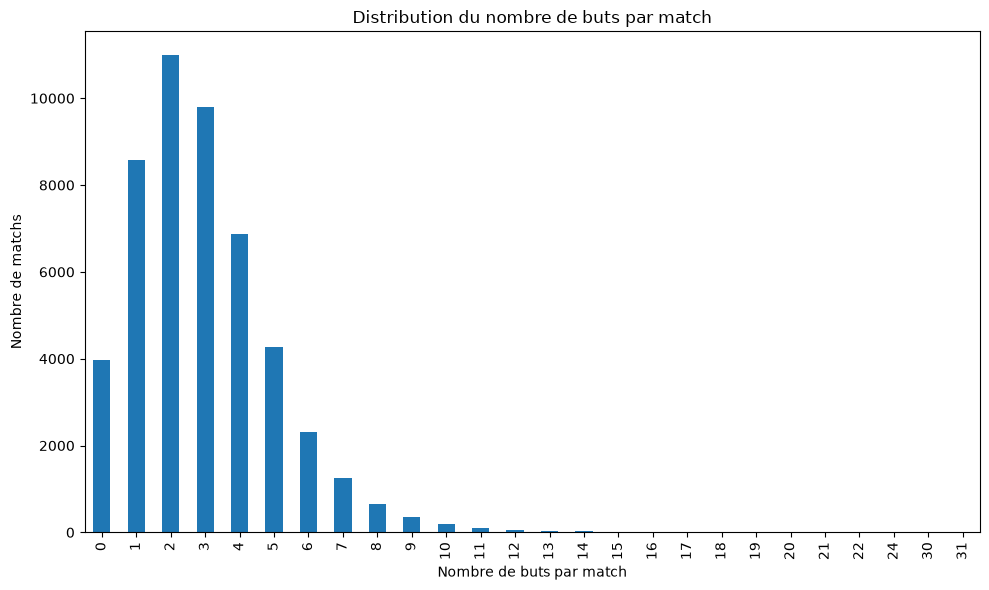

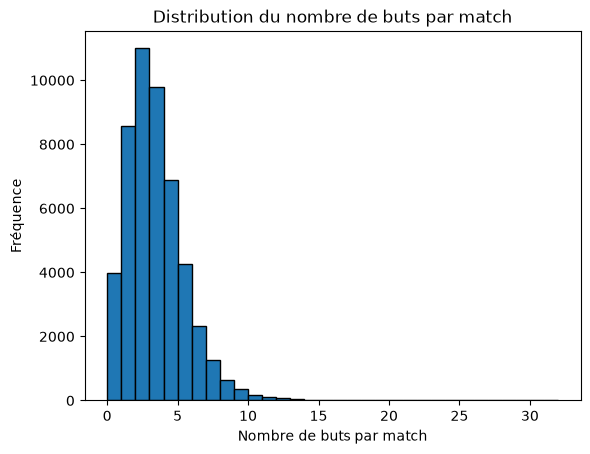

In [9]:
import pandas as pd
from src.config import load_config
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
color = ["#FE0162", "#345FFF", "#0ECDD0", "#F6970A", "#0B155B"]

CONFIG = load_config()
DATA_URL = CONFIG["external"]["match_result"]["csv_url"]
print(DATA_URL)

df = pd.read_csv(DATA_URL)

df = df.dropna(subset=["home_score", "away_score"])
df["total_goals"] = (df["home_score"] + df["away_score"]).astype(int)

high_band   = df["total_goals"].mean() + df["total_goals"].std()*3
low_band    = df["total_goals"].mean() - df["total_goals"].std()*3

salary_outlier_index = df[~((df["total_goals"] > low_band) & (df["total_goals"] < high_band))]
display(salary_outlier_index)

plt.figure(figsize=(10, 6))
df["total_goals"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Nombre de buts par match")
plt.ylabel("Nombre de matchs")
plt.title("Distribution du nombre de buts par match")
plt.tight_layout()
plt.savefig("distribution_buts.png")
plt.show()


plt.hist(df["total_goals"], bins=range(0, df["total_goals"].max()+2), edgecolor="black")
plt.xlabel("Nombre de buts par match")
plt.ylabel("Fréquence")
plt.title("Distribution du nombre de buts par match")
plt.show()
